II) RECOMBINATION  

 Assume standard values for all cosmological parameters you need.
1) Numerically solve the Saha-equation for the fraction of free electrons, Xe, as a function of temperature. Then solve it as a function of redshift. When does recombination happen?
2) Solve numerically the Boltzmann equation for the fraction of free electrons, given the equilibrium solution found above. When does recombination happen? How much did it change with respect to the previous result?

1)THEORETICAL BACKGROUND: The recombination era is a phase in the history of the universe when free electrons and protons combined to form neutral hydrogen as the universe cooled down. This transition marked the decoupling of radiation and matter and led to the release of the CMB radiation in a universe tat is no more opaque, but transparent.  

In particular, the relations:  
1) $e^- +\gamma <->e^- +\gamma $     compton/thomson scattering
2) $e^- +p^+ <->H +\gamma $     hydrogen recombination/ photo-dissociation

are in equilibrium at T>1 eV, as the temperature drops the photo-dissociation (->) stops and also the relation 1) becomes very rare because we have only neutral particles.  
We can define Xe as the free electron fraction on the total number of total baryonic particles: 
        $Xe= \frac{n_e}{n_b}$  
At the beginning the universe is fully ionized: every proton is associated with a free electron, so $Xe = 1$. As the universe expands and cools, electrons and protons combine to form neutral hydrogen atoms,so $Xe-> 0$. After recombination, the residual value of Xe decreases to about $10^{-4}$, since a tiny fraction of free electrons remains (is called "residual ionization").  
In order to have the value of Xe at each temperature, we can use the equation of Saha, that is:  
        $\frac{1 - X_e}{X_e^2} = 2\cdot\frac{\zeta(3)}{\pi^2} \, \eta_b \left( \frac{2\pi T}{m_e} \right)^{3/2} \exp\left(\frac{B}{T}\right)$  
where: $\zeta()$ is the zeta of Riemann, $\eta_b$ is the baryon to photon ratio and B is the binding energy of hydrogen.  
Saha equation allows us to calculate when recombination occurs. As said in Baumann book (page 92), we can consider that the recombination happened at Xe=0.5 .

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.optimize import brentq
from scipy.constants import m_e, k, pi, eV

k_B = 8.617333262e-5  # eV/K
T0 = 2.725  # temperatura attuale CMB in K
B = 13.6  # energia di ionizzazione in eV
m_e = 0.511e6  # massa dell'elettrone in eV
eta_b = 6e-10  # rapporto barioni/fotoni
zeta_3 = 1.202057 

# Intervallo di redshift z e temperature corrispondenti
z_values = np.linspace(1000, 1800, 300)
T_values = T0 * (1 + z_values) / 11604.5  # da K a eV

def f_T(T):
    return (2 * zeta_3 / np.pi**2) * eta_b * (2 * np.pi * T / m_e)**1.5 * np.exp(B / T)

def saha_implicit(X_e, T):
    lhs = (1 - X_e) / X_e**2
    rhs = f_T(T)
    return lhs - rhs

# Soluzione numerica per X_e(T)
X_e_numerical = []
for T in T_values:
    try:
        X = brentq(saha_implicit, 1e-8, 1.0, args=(T), xtol=1e-12)  #si cerca la radice dell'equazione nell'intervallo [1e-8, 1.0]
    except ValueError:
        X = 0.0  # fuori dal range risolvibile, assume ricombinazione completa
    X_e_numerical.append(X)


# Soluzione analitica per X_e(T)  (TROVATA SU LIBRO BAUMANN PAG 92)
def X_e_analytical_solution(T):
    f = f_T(T)
    return (-1 + np.sqrt(1 + 4 * f)) / (2 * f)
X_e_values = X_e_analytical_solution(T_values)

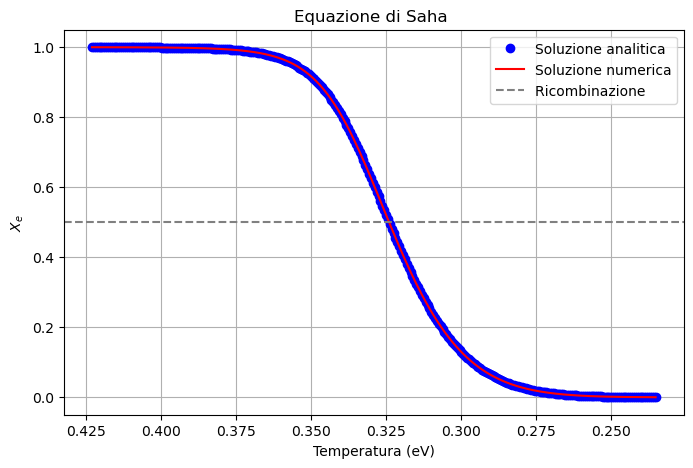

In [2]:
plt.figure(figsize=(8, 5))
plt.plot(T_values, X_e_values, 'o', color='blue', label='Soluzione analitica')
plt.plot(T_values, X_e_numerical, color='red', label='Soluzione numerica')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Ricombinazione ')
plt.gca().invert_xaxis()
plt.xlabel("Temperatura (eV)")
plt.ylabel("$X_e$")
#plt.yscale('log')
plt.title("Equazione di Saha ")
plt.grid(True)
plt.legend()
plt.show()

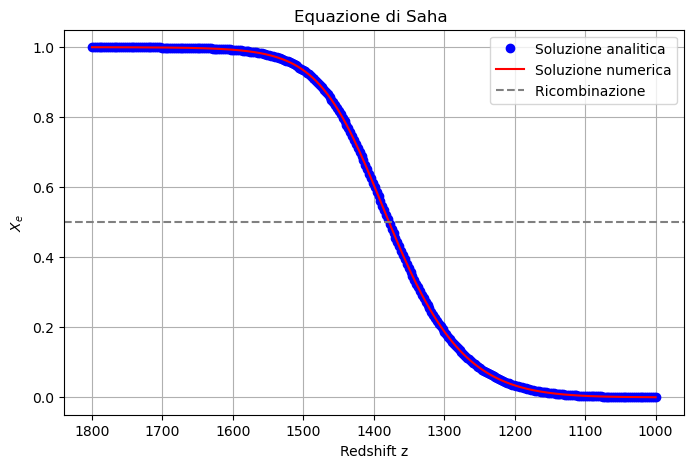

In [3]:
plt.figure(figsize=(8, 5))
plt.plot(z_values, X_e_values,'o', color='blue', label='Soluzione analitica')
plt.plot(z_values, X_e_numerical, color='red', label='Soluzione numerica')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Ricombinazione ')
plt.gca().invert_xaxis()
plt.xlabel("Redshift z")
plt.ylabel("$X_e$")
#plt.yscale('log')
plt.title("Equazione di Saha ")
plt.grid(True)
plt.legend()
plt.show()

In [4]:
def find_T_rec(T_array, Xe_array):
    for i in range(1, len(Xe_array)):
        if Xe_array[i-1] > 0.5 and Xe_array[i] <= 0.5:
            T1, T2 = T_array[i-1], T_array[i]
            X1, X2 = Xe_array[i-1], Xe_array[i]
            T_rec = T1 + (0.5 - X1) * (T2 - T1) / (X2 - X1)
            return T_rec
    return None

T_rec_saha = find_T_rec(T_values[::-1], X_e_numerical[::-1])
print(f"T_rec Saha = {T_rec_saha} eV")
T_rec_K = T_rec_saha / k_B  # da eV a K
z_rec_saha = T_rec_K / T0 - 1
print(f"z_rec Saha = {z_rec_saha}") 

T_rec Saha = 0.3238868423092968 eV
z_rec Saha = 1378.284671916767


NB: these are the results we expected for the Saha equation, however that equation in not accurate enough, so we have to move to Boltzmann equation , as the exercise suggests.  

NB2: Since matter-radiation equality is at $z_{eq}=3400$ we conclude that recombination (according to Saha equation) occurred in the matter-dominated era.

2)THEORETICAL BACKGROUND: While the Saha equation provides a good approximation for the ionization fraction under the assumption of chemical equilibrium, it becomes inaccurate as the universe expands and the recombination rate slows down relative to the Hubble expansion rate.In this regime, the number of recombinations per unit time is insufficient to maintain equilibrium, and Xe freezes out at a higher level than predicted by equilibrium calculations.  
To model this out-of-equilibrium evolution more accurately, it is necessary to solve the Boltzmann equation for Xe. This equation explicitly tracks the time derivative of the free electron fraction as a competition between the recombination rate and the photoionization rate (the relation 2) presented before).  
Comparing the Boltzmann solution to the Saha prediction highlights the impact of non-equilibrium effects, which are particularly important during the later stages of recombination when the ionization fraction drops rapidly by several orders of magnitude.
NB: The initial condition of the Boltzmann equation is the Saha solutions.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import zeta

T0 = 2.725  # K
k_B = 8.617333262e-5  # eV/K
B = 13.6  # eV
m_e = 0.511e6  # eV
eta_b = 6e-10

def f_x(x):
    T = B / x
    return (2 * zeta(3) / np.pi**2) * eta_b * (2 * np.pi * T / m_e)**1.5 * np.exp(x)

#soluzione analitica di Saha vista nella domanda precedente
def X_eq(x):
    f = f_x(x)
    return (-1 + np.sqrt(1 + 4 * f)) / (2 * f)

lambda_const = 4.0e3
def dXdx(x, X): #equazione di Boltzmann
    Xeq = X_eq(x)
    return -(lambda_const / x**2) * (X**2 - Xeq**2)

#range di integrazione
x_vals = np.linspace(30, 80, 300)  #con x = B/T
x_span = [x_vals[0], x_vals[-1]]
X0 = [1.0] #scelto da me

#uso metodo RK45 per la risoluzione
sol = solve_ivp(dXdx, x_span, X0, t_eval=x_vals, method='RK45', rtol=1e-8, atol=1e-10)
T_sol = B / sol.t

X_saha_vals = X_eq(x_vals)
T_vals = B / x_vals

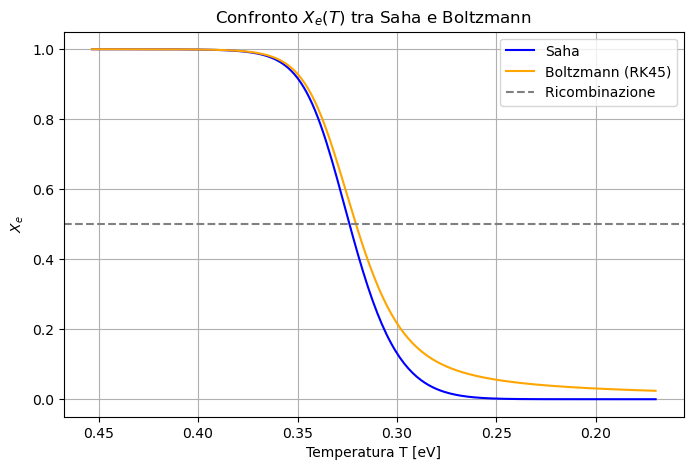

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(T_vals, X_saha_vals, label="Saha", color="blue")
plt.plot(T_sol, sol.y[0], label="Boltzmann (RK45)", color="orange")
plt.gca().invert_xaxis()
plt.axhline(y=0.5, color='gray', linestyle='--', label='Ricombinazione ')
plt.xlabel("Temperatura T [eV]")
plt.ylabel("$X_e$")
#plt.yscale('log')
#plt.ylim(1e-2, 3)
plt.title("Confronto $X_e(T)$ tra Saha e Boltzmann ")
plt.grid(True)
plt.legend()
plt.show()

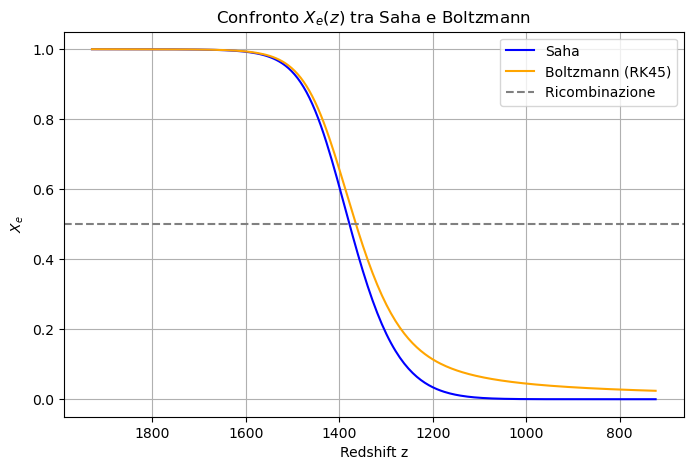

In [7]:
T0_eV = k_B * T0  # T0 in eV
z_vals = T_vals / T0_eV - 1
z_sol = T_sol / T0_eV - 1


plt.figure(figsize=(8, 5))
plt.plot(z_vals, X_saha_vals, label="Saha", color="blue")
plt.plot(z_sol, sol.y[0], label="Boltzmann (RK45)", color="orange")
plt.axhline(y=0.5, color='gray', linestyle='--', label='Ricombinazione ')
plt.gca().invert_xaxis()
plt.xlabel("Redshift z")
plt.ylabel("$X_e$")
#plt.yscale('log')
plt.title("Confronto $X_e(z)$ tra Saha e Boltzmann ")
plt.grid(True)
plt.legend()
plt.show()

In [8]:
def find_rec(T_array, z_array, Xe_array):
    for i in range(1, len(Xe_array)):
        if Xe_array[i-1] > 0.5 and Xe_array[i] <= 0.5:
            # Interpolazione lineare
            T1, T2 = T_array[i-1], T_array[i]
            z1, z2 = z_array[i-1], z_array[i]
            X1, X2 = Xe_array[i-1], Xe_array[i]
            T_rec = T1 + (0.5 - X1) * (T2 - T1) / (X2 - X1)
            z_rec = z1 + (0.5 - X1) * (z2 - z1) / (X2 - X1)
            return T_rec, z_rec
    return None
T_rec, z_rec = find_rec(T_sol, z_sol, sol.y[0])

print(f"T_rec Boltzmann = {T_rec} eV")
print(f"z_rec Boltzmann = {z_rec}")

T_rec Boltzmann = 0.32063410447357404 eV
z_rec Boltzmann = 1364.432761766333


NB: These values are slightly lower than those predicted by the Saha equation, reflecting the fact that recombination proceeds more gradually and freezes out earlier than in the idealized equilibrium scenario.